# HH2 - Step 5: Apply the Predictions - Generate action list
## (solar model, temperature model, designerly baseline model)

### Import libraries 

In [336]:
#Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn' ## disable chained assignment warnings due to false positives
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
#Plotly is a Python data visualization library 
import plotly.graph_objects as go
import plotly.express as px
import datetime as dt
import warnings
from datetime import datetime, timedelta

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Import metrics
from sklearn.ensemble import RandomForestRegressor

## Import weather forecast data

In [382]:
# api-endpoint
URL = "https://pro.openweathermap.org/data/2.5/forecast/hourly?lat=51.3135296&lon=4.83753463479851&appid=273a7bdc5f26d184400ce98d1bc8e957&units=metric"
 
# Sending a GET request to the specified URL to retrieve weather data
response = requests.get(url = URL)

# Extracting data from the response in JSON format
data = response.json()

# Flatten (normalize) the JSON file to create a DataFrame from the 'list' key
list = pd.json_normalize(data, record_path=['list'])  # Extract main data (list)
weather = pd.json_normalize(data, record_path=['list', 'weather'])  # Extract weather descriptions into a separate DataFrame

# Combining the main data and weather DataFrame, and dropping unnecessary columns
forecast = pd.concat([list, weather], axis=1)
forecast = forecast.drop(["visibility", "weather", 'description', 'main', "dt", "id", "pop", "main.feels_like", "main.pressure", "clouds.all", "wind.speed", "wind.deg", "wind.gust", "sys.pod", "rain.1h", "id", "icon", "main.sea_level", "main.grnd_level", "main.humidity", "main.temp_kf"], axis='columns')
forecast

,dt_txt,main.temp,main.temp_min,main.temp_max
0,2024-10-01 09:00:00,12.69,12.50,12.69
1,2024-10-01 10:00:00,12.72,12.72,12.83
2,2024-10-01 11:00:00,13.03,13.03,13.53
3,2024-10-01 12:00:00,13.58,13.58,14.18
4,2024-10-01 13:00:00,14.89,14.89,15.44
...,...,...,...,...
91,2024-10-05 04:00:00,6.75,6.75,6.75
92,2024-10-05 05:00:00,6.70,6.70,6.70
93,2024-10-05 06:00:00,6.59,6.59,6.59
94,2024-10-05 07:00:00,8.00,8.00,8.00


In [554]:
#json
import requests

# api-endpoint
URL = "https://pro.openweathermap.org/data/2.5/forecast/hourly?lat=51.3135296&lon=4.83753463479851&appid=273a7bdc5f26d184400ce98d1bc8e957&units=metric"
 
# Sending a GET request to the specified URL to retrieve weather data
response = requests.get(url = URL)

# Extracting data from the response in JSON format
data = response.json()

# Flatten (normalize) the JSON file to create a DataFrame from the 'list' key
list = pd.json_normalize(data, record_path=['list'])  # Extract main data (list)
weather = pd.json_normalize(data, record_path=['list', 'weather'])  # Extract weather descriptions into a separate DataFrame

# Combining the main data and weather DataFrame, and dropping unnecessary columns
forecast = pd.concat([list, weather], axis=1)
forecast = forecast.drop(["visibility", "weather", 'main', "dt", "id", "pop", "main.feels_like", "main.pressure", "clouds.all", "wind.speed", "wind.deg", "wind.gust", "sys.pod", "rain.1h", "id", "icon", "main.sea_level", "main.grnd_level", "main.humidity", "main.temp_kf"], axis='columns')

# Renaming columns for better readability and consistency
forecast = forecast.rename(columns={"dt_txt": "ts"}, errors="raise")
forecast = forecast.rename(columns={"main.temp": "Temperature_API"}, errors="raise")
forecast = forecast.rename(columns={"main.temp_min": "Temperature_API_MAX"}, errors="raise")
forecast = forecast.rename(columns={"main.temp_max": "Temperature_API_MIN"}, errors="raise")
forecast = forecast.rename(columns={"description": "weather_description"}, errors="raise")

# Converting the 'ts' column to datetime format
forecast['ts'] = pd.to_datetime(forecast['ts'])  # Turn timestamp into datetime dtype

# Getting the current time and adding one hour to it
start_time = datetime.now() + timedelta(hours=0)  # Set the start time to the next hour from the current time

# Filtering the forecast DataFrame to include only rows where the timestamp is greater than or equal to the start time
forecast = forecast[forecast['ts'] >= start_time]  # Keep only future forecasts starting from one hour from now

# Rounding temperature values to the nearest whole number
forecast = forecast.round(0)  # Round temperature to 0 decimal places

# Creating dummy variables for the weather descriptions, dropping the first category to avoid multicollinearity
forecast = pd.get_dummies(forecast, columns=['weather_description'], drop_first=True)

# Creating a complete list of possible weather descriptions
database_hourly =  pd.read_csv(r"C:\Users\20204113\OneDrive - TU Eindhoven\2_Research\Year4_CoolAI\Jupyter_notebooks\H2\DATA (backups)\1_hourly.csv")
all_weather_descriptions = database_hourly['weather_description'].unique()

# Adding missing categories as columns with default value 0, ensuring correct naming for dummy variables
for description in all_weather_descriptions:
    column_name = f'weather_description_{description}'  # Constructing the correct column name
    if column_name not in forecast.columns:
        forecast[column_name] = False  # Set default value to False for missing categories

# Extracting hour and date from the 'ts' column for further analysis
hours = forecast['ts'].dt.hour
date = forecast['ts'].dt.date
forecast['hr'] = hours  # Adding hour to the DataFrame
forecast['date'] = date  # Adding date to the DataFrame
forecast = forecast.drop(['date'], axis='columns')  # Dropping the 'date' column as it's no longer needed

# Filtering the forecast DataFrame to exclude rows where hour is between 22 and 23 or between 0 and 7
filtered_forecast = forecast[(forecast['hr'] < 23) & (forecast['hr'] > 6)]

# Selecting the first 12 rows of the filtered forecast DataFrame for display
filtered_forecast = filtered_forecast.head(12)
filtered_forecast

,ts,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,weather_description_clear sky,weather_description_few clouds,weather_description_light rain,weather_description_overcast clouds,weather_description_scattered clouds,weather_description_broken clouds,weather_description_moderate rain,weather_description_heavy intensity rain,hr
2,2024-10-01 12:00:00,14.0,14.0,14.0,False,False,False,True,False,False,False,False,12
3,2024-10-01 13:00:00,15.0,15.0,15.0,False,False,False,True,False,False,False,False,13
4,2024-10-01 14:00:00,16.0,16.0,16.0,False,False,True,False,False,False,False,False,14
5,2024-10-01 15:00:00,16.0,16.0,16.0,False,False,True,False,False,False,False,False,15
6,2024-10-01 16:00:00,15.0,15.0,15.0,False,False,True,False,False,False,False,False,16
7,2024-10-01 17:00:00,13.0,13.0,13.0,False,False,False,False,False,False,False,False,17
8,2024-10-01 18:00:00,12.0,12.0,12.0,False,False,False,False,False,False,False,False,18
9,2024-10-01 19:00:00,11.0,11.0,11.0,True,False,False,False,False,False,False,False,19
10,2024-10-01 20:00:00,10.0,10.0,10.0,True,False,False,False,False,False,False,False,20
11,2024-10-01 21:00:00,10.0,10.0,10.0,True,False,False,False,False,False,False,False,21


In [556]:
# Get the solar forecasts from the DF dataset
df_SolarAPI = pd.read_csv (r"https://data.id.tue.nl/datasets/downloadPublic/cytoZHE1NnlrQ20wNlJHRlU2MW1GNDlFTnhGNy8xcmpLSmJFVU8vRWYrbz0=")
df_SolarAPI = df_SolarAPI[["tijd_nl", "gr"]]
# df_SolarAPI['tijd_nl']
df_SolarAPI['ts'] = pd.to_datetime(df_SolarAPI['tijd_nl'], format="%d-%m-%Y %H:%M")  # Specify the correct format
df_SolarAPI = df_SolarAPI.drop(columns=['tijd_nl'])
df_SolarAPI.tail()

,gr,ts
643,68.0,2024-10-02 16:00:00
644,26.0,2024-10-02 17:00:00
645,10.0,2024-10-02 18:00:00
646,0.0,2024-10-02 19:00:00
647,0.0,2024-10-02 20:00:00


In [557]:
## merge the window dataframes on the timestamps for the last 72 hours
from functools import reduce
# Create a list of DataFrames to merge
dataframes_to_merge = [
    filtered_forecast,
    df_SolarAPI,
]

# Function to merge two DataFrames
def merge_asof(df1, df2):
    return pd.merge_asof(df1.sort_values('ts'), df2.sort_values('ts'), on='ts', tolerance=pd.Timedelta('120 min'))

# Use reduce to merge all DataFrames in one go
df_merge = reduce(merge_asof, dataframes_to_merge)
df_merge

,ts,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,weather_description_clear sky,weather_description_few clouds,weather_description_light rain,weather_description_overcast clouds,weather_description_scattered clouds,weather_description_broken clouds,weather_description_moderate rain,weather_description_heavy intensity rain,hr,gr
0,2024-10-01 12:00:00,14.0,14.0,14.0,False,False,False,True,False,False,False,False,12,4.0
1,2024-10-01 13:00:00,15.0,15.0,15.0,False,False,False,True,False,False,False,False,13,108.0
2,2024-10-01 14:00:00,16.0,16.0,16.0,False,False,True,False,False,False,False,False,14,101.0
3,2024-10-01 15:00:00,16.0,16.0,16.0,False,False,True,False,False,False,False,False,15,37.0
4,2024-10-01 16:00:00,15.0,15.0,15.0,False,False,True,False,False,False,False,False,16,22.0
5,2024-10-01 17:00:00,13.0,13.0,13.0,False,False,False,False,False,False,False,False,17,32.0
6,2024-10-01 18:00:00,12.0,12.0,12.0,False,False,False,False,False,False,False,False,18,4.0
7,2024-10-01 19:00:00,11.0,11.0,11.0,True,False,False,False,False,False,False,False,19,0.0
8,2024-10-01 20:00:00,10.0,10.0,10.0,True,False,False,False,False,False,False,False,20,0.0
9,2024-10-01 21:00:00,10.0,10.0,10.0,True,False,False,False,False,False,False,False,21,0.0


## Import the trained model to predict left and right light values

In [701]:
import joblib

# Load the trained models from disk
model_left = joblib.load('model_left.pkl')  # Load the left light model
model_right = joblib.load('model_right.pkl')  # Load the right light model

In [703]:
# # get a df from the merged dataset with the same structure as the training data to predict the light values
light_prediction = df_merge[["gr", 'hr']]

# Make predictions for the left light using the trained model
new_y_left_pred = model_left.predict(light_prediction)

# Make predictions for the right light using the trained model
new_y_right_pred = model_right.predict(light_prediction)

# If you want to add the predictions to the new DataFrame
light_prediction['light_left'] = new_y_left_pred
light_prediction['light_right'] = new_y_right_pred

light_prediction = light_prediction.drop(["gr"], axis='columns')

# Display the new DataFrame with predictions
# display(light_prediction)

In [705]:
## merge the window dataframes on the timestamps for the last 72 hours
from functools import reduce
# Create a list of DataFrames to merge
dataframes_to_merge = [
    filtered_forecast,
    light_prediction,
]

# Function to merge two DataFrames
def merge_asof(df1, df2):
    return pd.merge_asof(df1.sort_values('hr'), df2.sort_values('hr'), on='hr')

# Use reduce to merge all DataFrames in one go
df_full = reduce(merge_asof, dataframes_to_merge)

#order the dataframe according to the next 12 hours (identical to next 12h forecast)
forecast_hr = filtered_forecast[['hr']]
forecast_hr.rename(columns={'hr': 'hr_f'}, inplace=True)

df_full['hr'] = pd.Categorical(df_full['hr'], categories=forecast_hr['hr_f'], ordered=True)
ordered_df = df_full.sort_values('hr')
ordered_df.drop(['ts'], axis=1, inplace=True)
ordered_df = ordered_df.head(12)
ordered_df

,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,weather_description_clear sky,weather_description_few clouds,weather_description_light rain,weather_description_overcast clouds,weather_description_scattered clouds,weather_description_broken clouds,weather_description_moderate rain,weather_description_heavy intensity rain,hr,light_left,light_right
1,14.0,14.0,14.0,False,False,False,True,False,False,False,False,12,389.877500,239.375000
2,15.0,15.0,15.0,False,False,False,True,False,False,False,False,13,3604.490000,2949.750000
3,16.0,16.0,16.0,False,False,True,False,False,False,False,False,14,3532.110000,3025.230000
4,16.0,16.0,16.0,False,False,True,False,False,False,False,False,15,2307.180000,2278.660000
5,15.0,15.0,15.0,False,False,True,False,False,False,False,False,16,2569.580000,2205.050000
6,13.0,13.0,13.0,False,False,False,False,False,False,False,False,17,2270.600000,2471.660000
7,12.0,12.0,12.0,False,False,False,False,False,False,False,False,18,978.382857,819.345056
8,11.0,11.0,11.0,True,False,False,False,False,False,False,False,19,571.622869,513.774853
9,10.0,10.0,10.0,True,False,False,False,False,False,False,False,20,573.479823,505.618259
10,10.0,10.0,10.0,True,False,False,False,False,False,False,False,21,0.000000,0.000000


# Predict the action list + the max and min indoor temperature for the next 12 hours
## 1. Import action prediction model to construct the min and max action lists


In [851]:
import joblib

# Load the trained models from disk
model_action = joblib.load('model_action_window.pkl')  # Load the left light model
model_action.feature_names_in_  # Access the feature names used in training

array(['window_door', 'Temperature_API', 'Temperature_API_MAX',
       'Temperature_API_MIN', 'hr'], dtype=object)

In [853]:
df_hourly =  pd.read_csv(r"C:\Users\20204113\OneDrive - TU Eindhoven\2_Research\Year4_CoolAI\Jupyter_notebooks\H2\DATA (backups)\1_hourly.csv")
### Turn distance value into bool value (open/closed)
threshold = 50  # Define a threshold for distance
df_hourly['distance_left_open'] = df_hourly['distance_left'] > threshold  # True if distance_left is greater than threshold, else False
df_hourly['distance_right_open'] = df_hourly['distance_right'] > threshold  # True if distance_right is greater than threshold, else False
df_hourly.drop(columns=['distance_left', 'distance_right'], inplace=True)  # Remove original distance columns
df_hourly['window_door'] = df_hourly['window_door'].replace({0.0: False, 1.0: True})
df_hourly['door'] = df_hourly['door'].replace({0.0: False, 1.0: True})

# Remove rows with NaN values
# df_hourly.dropna(inplace=True)  # This line removes any rows that contain NaN values

# Select specific columns from the last row of df1
df_hourly = df_hourly[['Temperature_API', 'weather_description', 'Temperature_API_MAX', 'Temperature_API_MIN', 'window_door', 'light_right', 'light_left', 'hr']]
df_hourly = pd.get_dummies(df_hourly, columns=['weather_description'], drop_first=False)

last_row_values = df.iloc[-1]
new_row_df = pd.DataFrame([last_row_values])

# Append the new row to the top of result_df_min and result_df_max
ordered_df_new = pd.concat([new_row_df, ordered_df], ignore_index=True)
# ordered_df_new['Last_Temperature_indoor'] = ordered_df_new['Last_Temperature_indoor'].iloc[0]
ordered_df_new.fillna(0, inplace=True)
ordered_df_new

,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,window_door,light_right,light_left,door,hr,distance_left_open,distance_right_open,weather_description_broken clouds,weather_description_light rain,weather_description_moderate rain,weather_description_overcast clouds,weather_description_clear sky,weather_description_few clouds,weather_description_scattered clouds,weather_description_heavy intensity rain
0,13.28,14.91,11.9,False,2105.000000,0.000000,False,14,False,False,False,False,True,False,0,0,0,0
1,14.00,14.00,14.0,0,239.375000,389.877500,0,12,0,0,False,False,False,True,False,False,False,False
2,15.00,15.00,15.0,0,2949.750000,3604.490000,0,13,0,0,False,False,False,True,False,False,False,False
3,16.00,16.00,16.0,0,3025.230000,3532.110000,0,14,0,0,False,True,False,False,False,False,False,False
4,16.00,16.00,16.0,0,2278.660000,2307.180000,0,15,0,0,False,True,False,False,False,False,False,False
5,15.00,15.00,15.0,0,2205.050000,2569.580000,0,16,0,0,False,True,False,False,False,False,False,False
6,13.00,13.00,13.0,0,2471.660000,2270.600000,0,17,0,0,False,False,False,False,False,False,False,False
7,12.00,12.00,12.0,0,819.345056,978.382857,0,18,0,0,False,False,False,False,False,False,False,False
8,11.00,11.00,11.0,0,513.774853,571.622869,0,19,0,0,False,False,False,False,True,False,False,False
9,10.00,10.00,10.0,0,505.618259,573.479823,0,20,0,0,False,False,False,False,True,False,False,False


In [855]:
import pandas as pd
import numpy as np

# Create a list of possible values for the remaining parameters
values = [True, False]

# Create an empty DataFrame to store results
results = []

# Iterate over all combinations of the remaining parameters
for window_door in values:
    # for door in values:          
    #      for distance_left_open in values:
    #         for distance_right_open in values:
    # Create a new DataFrame for the current combination
    temp_df = ordered_df_new.copy()
    # temp_df['door'] = door
    # temp_df['distance_left_open'] = distance_left_open
    # temp_df['distance_right_open'] = distance_right_open
    temp_df['window_door'] = window_door

    # Ensure the features are in the same order as during training
    feature_order = model_action.feature_names_in_  # Access the feature names used in training
    # Reorder temp_df to match the feature order
    temp_df = temp_df[feature_order]
    
    # Predict indoor temperature
    temp_df['Temperature_indoor'] = model_action.predict(temp_df)

    # Append results to the list
    results.append(temp_df)

all_results = pd.concat(results)
all_results = all_results.reset_index(drop=True)
all_results

,window_door,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,hr,Temperature_indoor
0,True,13.28,14.91,11.9,14,-0.680777
1,True,14.00,14.00,14.0,12,-0.875788
2,True,15.00,15.00,15.0,13,-0.688506
3,True,16.00,16.00,16.0,14,-0.453660
4,True,16.00,16.00,16.0,15,-0.486954
5,True,15.00,15.00,15.0,16,-0.612404
6,True,13.00,13.00,13.0,17,-1.118957
7,True,12.00,12.00,12.0,18,-0.935242
8,True,11.00,11.00,11.0,19,-1.060692
9,True,10.00,10.00,10.0,20,-1.322887


## Making lists for actions that lead to minimum indoor temperatures and actions that lead to maximum indoor temperatures

In [857]:
# Group by 'hr' and get the index of the min and max 'Temperature_indoor'
max_temp_indices  = all_results.groupby('hr', observed=False)['Temperature_indoor'].idxmax()
min_temp_indices  = all_results.groupby('hr', observed=False)['Temperature_indoor'].idxmin()

# Filter the DataFrame to keep only the rows with the highest temperature for each hour
result_df_max = all_results.loc[max_temp_indices]
result_df_min = all_results.loc[min_temp_indices]

# Display the resulting DataFrame
result_df_max.drop_duplicates()
result_df_min.drop_duplicates()

display(result_df_min)
display(result_df_max)

,window_door,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,hr,Temperature_indoor
12,True,10.00,10.00,10.0,7,-1.585082
1,True,14.00,14.00,14.0,12,-0.875788
2,True,15.00,15.00,15.0,13,-0.688506
0,True,13.28,14.91,11.9,14,-0.680777
4,True,16.00,16.00,16.0,15,-0.486954
5,True,15.00,15.00,15.0,16,-0.612404
6,True,13.00,13.00,13.0,17,-1.118957
7,True,12.00,12.00,12.0,18,-0.935242
8,True,11.00,11.00,11.0,19,-1.060692
9,True,10.00,10.00,10.0,20,-1.322887


,window_door,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,hr,Temperature_indoor
12,True,10.0,10.0,10.0,7,-1.585082
14,False,14.0,14.0,14.0,12,-0.826440
15,False,15.0,15.0,15.0,13,-0.639158
16,False,16.0,16.0,16.0,14,-0.262810
17,False,16.0,16.0,16.0,15,-0.255081
18,False,15.0,15.0,15.0,16,-0.577325
19,False,13.0,13.0,13.0,17,-1.017290
20,False,12.0,12.0,12.0,18,-0.883517
21,False,11.0,11.0,11.0,19,-1.039288
9,True,10.0,10.0,10.0,20,-1.322887


## Extract action list for min and max temperature

#### Minimum

In [325]:
# Initialize an empty list to store the actions that need to be taken
actions_list = []

# Function to check for changes in a specified column and record the actions
def check_for_changes(df, column_name, action_open, action_close):
    # Iterate through the DataFrame to find changes in the specified column
    for i in range(1, len(df)):
        # Check if the value in the current row is different from the previous row
        if df[column_name].iloc[i] != df[column_name].iloc[i - 1]:
            # Determine the time (hr) for the action
            action_time = df['hr'].iloc[i]  # Use the previous row's hour
            # Get the corresponding indoor temperature
            indoor_temperature = df['trend'].iloc[i]
            # Calculate the difference in indoor temperature with the previous row
            temperature_difference = indoor_temperature - df['trend'].iloc[i - 1]  # Compute the temperature change
            # Determine the action based on the change from False to True or True to False
            action = action_open if df[column_name].iloc[i] else action_close
            # Append the action details to the actions list
            actions_list.append({
                'time': f"{action_time}:00",  # Format the time as HH:MM
                'hr': action_time,
                'action': action,              # Description of the action
                # 'indoor_temperature': indoor_temperature,  # Corresponding indoor temperature
                # 'temperature_difference': temperature_difference  # Add the difference in indoor temperature from the previous row
            })

# Check for changes in the 'door' column of result_df_min and result_df_max
check_for_changes(result_df_min, 'door', 'open door', 'close door')

# Check for changes in the 'window_door' column of result_df_min and result_df_max
check_for_changes(result_df_min, 'window_door', 'open window', 'close window')

# Check for changes in the 'distance_left_open' column of result_df_min and result_df_max
check_for_changes(result_df_min, 'distance_left_open', 'open left curtain', 'close left curtain')

# Check for changes in the 'distance_right_open' column of result_df_min and result_df_max
check_for_changes(result_df_min, 'distance_right_open', 'open right curtain', 'close right curtain')

# Create a DataFrame from the actions list
actions_df = pd.DataFrame(actions_list)

# #order the dataframe according to the next 12 hours (identical to next 12h forecast)
# actions_df['hr'] = pd.Categorical(actions_df['hr'], categories=forecast_hr['hr_f'], ordered=True)
# ordered_df = actions_df.sort_values('hr')
# ordered_df_min = ordered_df.drop(["hr"], axis='columns') # drop 'hr' since we dont need it anymore


# Display the resulting actions DataFrame
actions_df

,time,hr,action
0,21:00,21,close door
1,8:00,8,open door
2,20:00,20,close window
3,21:00,21,open window
4,8:00,8,close window
5,10:00,10,open window


#### Maximum

In [323]:
# Initialize an empty list to store the actions that need to be taken
actions_list = []

# Function to check for changes in a specified column and record the actions
def check_for_changes(df, column_name, action_open, action_close):
    # Iterate through the DataFrame to find changes in the specified column
    for i in range(1, len(df)):
        # Check if the value in the current row is different from the previous row
        if df[column_name].iloc[i] != df[column_name].iloc[i - 1]:
            # Determine the time (hr) for the action
            action_time = df['hr'].iloc[i]  # Use the previous row's hour
            # Get the corresponding indoor temperature
            indoor_temperature = df['trend'].iloc[i]
            # Calculate the difference in indoor temperature with the previous row
            temperature_difference = indoor_temperature - df['trend'].iloc[i - 1]  # Compute the temperature change
            # Determine the action based on the change from False to True or True to False
            action = action_open if df[column_name].iloc[i] else action_close
            # Append the action details to the actions list
            actions_list.append({
                'time': f"{action_time}:00",  # Format the time as HH:MM
                'hr': action_time,
                'action': action,              # Description of the action
                # 'indoor_temperature': indoor_temperature,  # Corresponding indoor temperature
                # 'temperature_difference': temperature_difference  # Add the difference in indoor temperature from the previous row
            })

# Check for changes in the 'door' column of result_df_min and result_df_max
check_for_changes(result_df_max, 'door', 'open door', 'close door')

# Check for changes in the 'window_door' column of result_df_min and result_df_max
check_for_changes(result_df_max, 'window_door', 'open window', 'close window')

# Check for changes in the 'distance_left_open' column of result_df_min and result_df_max
check_for_changes(result_df_max, 'distance_left_open', 'open left curtain', 'close left curtain')

# Check for changes in the 'distance_right_open' column of result_df_min and result_df_max
check_for_changes(result_df_max, 'distance_right_open', 'open right curtain', 'close right curtain')

# Create a DataFrame from the actions list
actions_df = pd.DataFrame(actions_list)

# #order the dataframe according to the next 12 hours (identical to next 12h forecast)
# actions_df['hr'] = pd.Categorical(actions_df['hr'], categories=forecast_hr['hr_f'], ordered=True)
# ordered_df = actions_df.sort_values('hr')
# ordered_df_min = ordered_df.drop(["hr"], axis='columns') # drop 'hr' since we dont need it anymore


# Display the resulting actions DataFrame
actions_df

,time,hr,action
0,7:00,7,open door
1,8:00,8,close door
2,7:00,7,open window
3,8:00,8,close window


## 2.  Import temperature prediction model to predict max and min indoor temperatures 

In [288]:
import joblib

# Load the trained models from disk
model_action = joblib.load('model_temp.pkl')  # Load the left light model
model_action.feature_names_in_  # Access the feature names used in training

array(['Temperature_API', 'Temperature_API_MAX', 'Temperature_API_MIN',
       'light_left', 'light_right', 'hr', 'weather_main_Clear',
       'weather_main_Clouds', 'weather_main_Rain', 'window_open_duration',
       'window_closed_duration', 'door_open_duration',
       'door_closed_duration', 'distance_left_open_duration',
       'distance_left_closed_duration', 'distance_right_open_duration',
       'distance_right_closed_duration', 'temperature_last'], dtype=object)

### Load and view historical data (starting point)

In [290]:
df_hourly =  pd.read_csv(r"C:\Users\20204113\OneDrive - TU Eindhoven\2_Research\Year4_CoolAI\Jupyter_notebooks\H2\DATA (backups)\1_hourly.csv")
### Turn distance value into bool value (open/closed)
threshold = 50  # Define a threshold for distance
df_hourly['distance_left_open'] = df_hourly['distance_left'] > threshold  # True if distance_left is greater than threshold, else False
df_hourly['distance_right_open'] = df_hourly['distance_right'] > threshold  # True if distance_right is greater than threshold, else False
df_hourly.drop(columns=['distance_left', 'distance_right'], inplace=True)  # Remove original distance columns
df_hourly['window_door'] = df_hourly['window_door'].replace({0.0: False, 1.0: True})
df_hourly['door'] = df_hourly['door'].replace({0.0: False, 1.0: True})

# Remove rows with NaN values
# df_hourly.dropna(inplace=True)  # This line removes any rows that contain NaN values
df_hourly = pd.get_dummies(df_hourly, columns=['weather_main'], drop_first=False)
df = df_hourly.tail(24)


# Select specific columns from the last row of df1
selected_columns = ['Temperature_API', 'Temperature_API_MAX', 'Temperature_API_MIN', 'window_door', 'light_right', 'light_left', 'door', 'hr', 'distance_left_open', 'distance_right_open', 'weather_main_Clear', 'weather_main_Clouds', 'weather_main_Rain', 'Temperature_indoor']
last_row_values = df[selected_columns].iloc[-1]

# Create a new DataFrame from the last row values
new_row_df = pd.DataFrame([last_row_values])
# new_row_df = new_row_df.rename(columns={"Temperature_indoor": "trend"}, errors="raise")

# Append the new row to the top of result_df_min and result_df_max
result_df_min = pd.concat([new_row_df, result_df_min], ignore_index=True)
result_df_max = pd.concat([new_row_df, result_df_max], ignore_index=True)

result_df_min

,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,window_door,light_right,light_left,door,hr,distance_left_open,distance_right_open,weather_main_Clear,weather_main_Clouds,weather_main_Rain,Temperature_indoor,trend
0,13.28,14.91,11.9,False,2105.000000,NaN,False,14,False,False,False,False,True,19.3,NaN
1,14.00,14.00,14.0,True,852.164667,857.590000,True,15,True,True,False,False,True,NaN,22.015633
2,15.00,15.00,15.0,True,914.347857,866.620833,True,16,True,True,False,True,False,NaN,22.043567
3,15.00,15.00,15.0,True,1197.497593,1015.761962,True,17,True,True,False,True,False,NaN,22.040000
4,15.00,15.00,15.0,True,1213.047593,1045.481962,True,18,True,True,False,True,False,NaN,22.054467
5,14.00,14.00,14.0,True,513.774853,571.622869,True,19,True,True,False,True,False,NaN,22.097667
6,14.00,14.00,14.0,False,505.618259,573.479823,True,20,True,True,False,True,False,NaN,22.094031
7,14.00,14.00,14.0,True,0.000000,0.000000,False,21,True,True,False,True,False,NaN,22.158074
8,14.00,14.00,14.0,True,0.000000,0.000000,False,22,True,True,False,False,True,NaN,22.160991
9,12.00,12.00,12.0,True,2.265000,6.700000,False,7,True,True,False,True,False,NaN,21.895585


In [299]:
# result_df_min.drop(['trend'], axis=1, inplace=True)
df = result_df_min


# Create cumulative features for "window_door"
df['window_door'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
df['window_door'] = df['window_door'].astype(int)
df['window_open_duration'] = df['window_door'].groupby((df['window_door'] != df['window_door'].shift()).cumsum()).cumsum()  # Count consecutive open periods
df['window_closed_duration'] = (df['window_door'] == 0).astype(int)  # Create a binary column where 1 indicates the window is closed
df['window_closed_duration'] = df['window_closed_duration'].groupby((df['window_closed_duration'] != df['window_closed_duration'].shift(6)).cumsum()).cumsum()  # Count consecutive closed periods

# Create consecutive counts for 'door'
df['door'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
df['door'] = df['door'].astype(int)  # Convert 'door' to integer (1 for open, 0 for closed)
df['door_open_duration'] = df['door'].groupby((df['door'] != df['door'].shift()).cumsum()).cumsum()  # Count consecutive open periods for door
df['door_closed_duration'] = (df['door'] == 0).astype(int)  # Create a binary column for closed door
df['door_closed_duration'] = df['door_closed_duration'].groupby((df['door_closed_duration'] != df['door_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods for door

# Create consecutive counts for 'distance_left_open'
df['distance_left_open'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
df['distance_left_open'] = df['distance_left_open'].astype(int)  # Convert 'door' to integer (1 for open, 0 for closed)
df['distance_left_open_duration'] = df['distance_left_open'].groupby((df['distance_left_open'] != df['distance_left_open'].shift()).cumsum()).cumsum()  # Count consecutive open periods for door
df['distance_left_closed_duration'] = (df['distance_left_open'] == 0).astype(int)  # Create a binary column for closed door
df['distance_left_closed_duration'] = df['distance_left_closed_duration'].groupby((df['distance_left_closed_duration'] != df['distance_left_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods

# Create consecutive counts for 'distance_right_open'
df['distance_right_open'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
df['distance_right_open'] = df['distance_right_open'].astype(int)  # Convert 'door' to integer (1 for open, 0 for closed)
df['distance_right_open_duration'] = df['distance_right_open'].groupby((df['distance_right_open'] != df['distance_right_open'].shift()).cumsum()).cumsum()  # Count consecutive open periods for door
df['distance_right_closed_duration'] = (df['distance_right_open'] == 0).astype(int)  # Create a binary column for closed door
df['distance_right_closed_duration'] = df['distance_right_closed_duration'].groupby((df['distance_right_closed_duration'] != df['distance_right_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods

df

,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,window_door,light_right,light_left,door,hr,distance_left_open,distance_right_open,...,weather_main_Rain,Temperature_indoor,window_open_duration,window_closed_duration,door_open_duration,door_closed_duration,distance_left_open_duration,distance_left_closed_duration,distance_right_open_duration,distance_right_closed_duration
0,13.28,14.91,11.9,0,2105.000000,NaN,0,14,0,0,...,True,19.3,0,1,0,1,0,1,0,1
1,14.00,14.00,14.0,1,852.164667,857.590000,1,15,1,1,...,True,NaN,1,0,1,0,1,0,1,0
2,15.00,15.00,15.0,1,914.347857,866.620833,1,16,1,1,...,False,NaN,2,0,2,0,2,0,2,0
3,15.00,15.00,15.0,1,1197.497593,1015.761962,1,17,1,1,...,False,NaN,3,0,3,0,3,0,3,0
4,15.00,15.00,15.0,1,1213.047593,1045.481962,1,18,1,1,...,False,NaN,4,0,4,0,4,0,4,0
5,14.00,14.00,14.0,1,513.774853,571.622869,1,19,1,1,...,False,NaN,5,0,5,0,5,0,5,0
6,14.00,14.00,14.0,0,505.618259,573.479823,1,20,1,1,...,False,NaN,0,1,6,0,6,0,6,0
7,14.00,14.00,14.0,1,0.000000,0.000000,0,21,1,1,...,False,NaN,1,1,0,1,7,0,7,0
8,14.00,14.00,14.0,1,0.000000,0.000000,0,22,1,1,...,True,NaN,2,1,0,2,8,0,8,0
9,12.00,12.00,12.0,1,2.265000,6.700000,0,7,1,1,...,False,NaN,3,1,0,3,9,0,9,0


In [305]:
df.drop(['door', 'window_door', 'distance_left_open', 'distance_right_open'], axis=1, inplace=True)
df

,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,light_right,light_left,hr,weather_main_Clear,weather_main_Clouds,weather_main_Rain,Temperature_indoor,window_open_duration,window_closed_duration,door_open_duration,door_closed_duration,distance_left_open_duration,distance_left_closed_duration,distance_right_open_duration,distance_right_closed_duration
0,13.28,14.91,11.9,2105.000000,NaN,14,False,False,True,19.3,0,1,0,1,0,1,0,1
1,14.00,14.00,14.0,852.164667,857.590000,15,False,False,True,NaN,1,0,1,0,1,0,1,0
2,15.00,15.00,15.0,914.347857,866.620833,16,False,True,False,NaN,2,0,2,0,2,0,2,0
3,15.00,15.00,15.0,1197.497593,1015.761962,17,False,True,False,NaN,3,0,3,0,3,0,3,0
4,15.00,15.00,15.0,1213.047593,1045.481962,18,False,True,False,NaN,4,0,4,0,4,0,4,0
5,14.00,14.00,14.0,513.774853,571.622869,19,False,True,False,NaN,5,0,5,0,5,0,5,0
6,14.00,14.00,14.0,505.618259,573.479823,20,False,True,False,NaN,0,1,6,0,6,0,6,0
7,14.00,14.00,14.0,0.000000,0.000000,21,False,True,False,NaN,1,1,0,1,7,0,7,0
8,14.00,14.00,14.0,0.000000,0.000000,22,False,False,True,NaN,2,1,0,2,8,0,8,0
9,12.00,12.00,12.0,2.265000,6.700000,7,False,True,False,NaN,3,1,0,3,9,0,9,0


In [311]:
df['temperature_last'] = df['Temperature_indoor'].iloc[0]
df.drop(['Temperature_indoor'], axis=1, inplace=True)

df

,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,light_right,light_left,hr,weather_main_Clear,weather_main_Clouds,weather_main_Rain,window_open_duration,window_closed_duration,door_open_duration,door_closed_duration,distance_left_open_duration,distance_left_closed_duration,distance_right_open_duration,distance_right_closed_duration,temperature_last
0,13.28,14.91,11.9,2105.000000,NaN,14,False,False,True,0,1,0,1,0,1,0,1,19.3
1,14.00,14.00,14.0,852.164667,857.590000,15,False,False,True,1,0,1,0,1,0,1,0,19.3
2,15.00,15.00,15.0,914.347857,866.620833,16,False,True,False,2,0,2,0,2,0,2,0,19.3
3,15.00,15.00,15.0,1197.497593,1015.761962,17,False,True,False,3,0,3,0,3,0,3,0,19.3
4,15.00,15.00,15.0,1213.047593,1045.481962,18,False,True,False,4,0,4,0,4,0,4,0,19.3
5,14.00,14.00,14.0,513.774853,571.622869,19,False,True,False,5,0,5,0,5,0,5,0,19.3
6,14.00,14.00,14.0,505.618259,573.479823,20,False,True,False,0,1,6,0,6,0,6,0,19.3
7,14.00,14.00,14.0,0.000000,0.000000,21,False,True,False,1,1,0,1,7,0,7,0,19.3
8,14.00,14.00,14.0,0.000000,0.000000,22,False,False,True,2,1,0,2,8,0,8,0,19.3
9,12.00,12.00,12.0,2.265000,6.700000,7,False,True,False,3,1,0,3,9,0,9,0,19.3


In [307]:
model_action.feature_names_in_  # Access the feature names used in training

array(['Temperature_API', 'Temperature_API_MAX', 'Temperature_API_MIN',
       'light_left', 'light_right', 'hr', 'weather_main_Clear',
       'weather_main_Clouds', 'weather_main_Rain', 'window_open_duration',
       'window_closed_duration', 'door_open_duration',
       'door_closed_duration', 'distance_left_open_duration',
       'distance_left_closed_duration', 'distance_right_open_duration',
       'distance_right_closed_duration', 'temperature_last'], dtype=object)

In [315]:
df = df.drop(index=0).reset_index(drop=True)


In [317]:
# Ensure the features are in the same order as during training
feature_order = model_action.feature_names_in_  # Access the feature names used in training
# Reorder temp_df to match the feature order
df = df[feature_order]

# Predict indoor temperature
df['Predicted_temperature_indoor'] = model_action.predict(df)
df

,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,light_left,light_right,hr,weather_main_Clear,weather_main_Clouds,weather_main_Rain,window_open_duration,window_closed_duration,door_open_duration,door_closed_duration,distance_left_open_duration,distance_left_closed_duration,distance_right_open_duration,distance_right_closed_duration,temperature_last,Predicted_temperature_indoor
0,14.0,14.0,14.0,857.590000,852.164667,15,False,False,True,1,0,1,0,1,0,1,0,19.3,21.424
1,15.0,15.0,15.0,866.620833,914.347857,16,False,True,False,2,0,2,0,2,0,2,0,19.3,21.663
2,15.0,15.0,15.0,1015.761962,1197.497593,17,False,True,False,3,0,3,0,3,0,3,0,19.3,21.703
3,15.0,15.0,15.0,1045.481962,1213.047593,18,False,True,False,4,0,4,0,4,0,4,0,19.3,21.682
4,14.0,14.0,14.0,571.622869,513.774853,19,False,True,False,5,0,5,0,5,0,5,0,19.3,21.395
5,14.0,14.0,14.0,573.479823,505.618259,20,False,True,False,0,1,6,0,6,0,6,0,19.3,21.441
6,14.0,14.0,14.0,0.000000,0.000000,21,False,True,False,1,1,0,1,7,0,7,0,19.3,21.429
7,14.0,14.0,14.0,0.000000,0.000000,22,False,False,True,2,1,0,2,8,0,8,0,19.3,21.400
8,12.0,12.0,12.0,6.700000,2.265000,7,False,True,False,3,1,0,3,9,0,9,0,19.3,21.205
9,13.0,13.0,13.0,6.700000,2.265000,8,False,True,False,0,1,1,0,10,0,10,0,19.3,21.266


In [270]:
# Fill the 'Temperature_indoor' column based on the previous row's value and the current row's trend
for i in range(1, len(result_df_min)):
    result_df_min['Temperature_indoor'].iloc[i] = result_df_min['Temperature_indoor'].iloc[i-1] + result_df_min['trend'].iloc[i]

result_df_min

,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,window_door,light_right,light_left,door,hr,distance_left_open,distance_right_open,weather_main_Clear,weather_main_Clouds,weather_main_Rain,Temperature_indoor,trend
0,13.28,14.91,11.9,False,2105.000000,NaN,False,14,False,False,False,False,True,19.300000,NaN
1,14.00,14.00,14.0,False,852.164667,857.590000,True,15,True,True,False,False,True,19.211329,-0.088671
2,15.00,15.00,15.0,False,914.347857,866.620833,True,16,True,True,False,True,False,19.123965,-0.087364
3,15.00,15.00,15.0,True,1197.497593,1015.761962,True,17,True,False,False,True,False,19.025039,-0.098925
4,15.00,15.00,15.0,False,1213.047593,1045.481962,True,18,True,True,False,True,False,18.944097,-0.080942
5,14.00,14.00,14.0,False,513.774853,571.622869,True,19,True,True,False,True,False,18.854313,-0.089784
6,14.00,14.00,14.0,True,505.618259,573.479823,False,20,True,False,False,True,False,18.773286,-0.081027
7,14.00,14.00,14.0,True,0.000000,0.000000,False,21,True,False,False,True,False,18.701208,-0.072078
8,14.00,14.00,14.0,True,0.000000,0.000000,False,22,True,False,False,False,True,18.635606,-0.065602
9,12.00,12.00,12.0,True,2.265000,6.700000,True,7,True,True,False,True,False,18.207088,-0.428518


In [301]:
# Fill the 'Temperature_indoor' column based on the previous row's value and the current row's trend
for i in range(1, len(result_df_max)):
    result_df_max['Temperature_indoor'].iloc[i] = result_df_max['Temperature_indoor'].iloc[i-1] + result_df_max['trend'].iloc[i]

result_df_max

,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,window_door,light_right,light_left,door,hr,distance_left_open,distance_right_open,weather_main_Clear,weather_main_Clouds,weather_main_Rain,Temperature_indoor,trend
0,13.28,14.91,11.9,False,2105.000000,NaN,False,14,False,False,False,False,True,19.300000,NaN
1,14.00,14.00,14.0,False,852.164667,857.590000,False,15,False,False,False,False,True,42.147120,22.847120
2,15.00,15.00,15.0,False,914.347857,866.620833,False,16,False,False,False,True,False,65.462291,23.315171
3,15.00,15.00,15.0,False,1197.497593,1015.761962,False,17,False,False,False,True,False,88.804700,23.342409
4,15.00,15.00,15.0,False,1213.047593,1045.481962,False,18,False,False,False,True,False,112.176043,23.371343
5,14.00,14.00,14.0,False,513.774853,571.622869,False,19,False,False,False,True,False,135.040122,22.864079
6,14.00,14.00,14.0,False,505.618259,573.479823,False,20,False,False,False,True,False,157.897867,22.857746
7,14.00,14.00,14.0,False,0.000000,0.000000,False,21,False,False,False,True,False,180.789158,22.891291
8,14.00,14.00,14.0,False,0.000000,0.000000,False,22,False,False,False,False,True,203.559588,22.770430
9,12.00,12.00,12.0,True,2.265000,6.700000,True,7,False,False,False,True,False,225.554439,21.994852


# Send to DF entity dataframe

In [370]:
actions_df['actions_count'] = len(actions_df)
actions_df['max_temp'] = 23.5
actions_df['min_temp'] = 21.2


# pad with rows to ensure that each time the same length dataframe is sent
desired_length = 15

# Calculate how many empty rows are needed
rows_to_add = desired_length - len(actions_df)

# Create a DataFrame with empty rows
if rows_to_add > 0:
    zero_rows = pd.DataFrame('', index=range(rows_to_add), columns=actions_df.columns)
    # Concatenate the original DataFrame with the zero rows
    actions_df_final = pd.concat([actions_df, zero_rows], ignore_index=True)
    
# Convert specified columns to strings, as only strings can be passed as JSON parameters
columns_to_convert = ['time', 'hr', 'action', 'actions_count', 
                      'max_temp', 'min_temp']
actions_df_final[columns_to_convert] = actions_df_final[columns_to_convert].map(str)
actions_df_final.dtypes

time             object
hr               object
action           object
actions_count    object
max_temp         object
min_temp         object
dtype: object

In [372]:
# Reverse the dataframe so that the JSON will eventually be sent in the right order
actions_df_final = actions_df_final.reindex(index=actions_df_final.index[::-1]) # reverse the dataframe so that the JSON will eventually be sent in the right order
#get a string id per row to pass as unique resource_id
actions_df_final.reset_index(inplace=True, drop=True)
actions_df_final["id"] = actions_df_final.index + 1
actions_df_final['id'] = actions_df_final['id'].map(str)
actions_df_final.head()

,time,hr,action,actions_count,max_temp,min_temp,id
0,,,,,,,1
1,,,,,,,2
2,,,,,,,3
3,,,,,,,4
4,,,,,,,5


In [374]:
def post_data_to_api(df, url, api_token):
    """
    Function to post data to the specified API endpoint using the provided dataframe.
    
    Parameters:
    df (DataFrame): The dataframe containing the data to be sent.
    url (str): The API endpoint URL.
    api_token (str): The API token for authentication.
    """
    # Loop through the dataframe to add rows to the DF dataset as JSON
    for ind in df.index:
        # Create a dictionary for headers to be sent to the API
        HEADERS = {
            'api_token': api_token,  # API token for authentication
            'resource_id': df["id"].iloc[ind],  # Resource ID from the dataframe
            'token': 'token_for_identifier'  # Token for additional authentication
        }
        
        # Extract parameters from the dataframe for the current index
        time = df['time'].iloc[ind]
        hr = df['hr'].iloc[ind]
        action = df['action'].iloc[ind]
        actions_count = df['actions_count'].iloc[ind]
        max_temp = df['max_temp'].iloc[ind]
        min_temp = df['min_temp'].iloc[ind]
        
        # Prepare the parameters to be sent in the POST request
        PARAMS = {
            "time": time, 
            "hr": hr, 
            "action": action, 
            "actions_count": actions_count, 
            "max_temp": max_temp, 
            "min_temp": min_temp, 
        }    
        
        # Send a POST request to the API with the headers and parameters
        r = requests.post(url=url, headers=HEADERS, json=PARAMS)

url_actionlist = "https://data.id.tue.nl/datasets/entity/11929/item/"
api_token_actionlist = "ZkRITHNheFFvR2VsUE1FY3pTeFVPcjljaG81WldkMW1sd1lwbTNRNmY0dz0="  


# Call the function for each dataframe
post_data_to_api(actions_df_final, url_actionlist, api_token_actionlist)

## Predict the temperatures for the min and max dataframes

In [81]:
database_hourly =  pd.read_csv(r"C:\Users\20204113\OneDrive - TU Eindhoven\2_Research\Year4_CoolAI\Jupyter_notebooks\H2\DATA (backups)\1_hourly.csv")
database_hourly['ts'] = pd.to_datetime(database_hourly['ts'])  # Specify the correct format
database_hourly.drop(['weather_main', 'shade_left', 'shade_right', 'curtain_left', 'curtain_right'], axis=1, inplace=True)

### Turn distance value into bool value (open/closed)
# Define a threshold for distance
threshold = 50  # Example threshold value; adjust based on your data

# Convert distance_left and distance_right to boolean values
database_hourly['distance_left_open'] = database_hourly['distance_left'] > threshold  # True if distance_left is greater than threshold, else False
database_hourly['distance_right_open'] = database_hourly['distance_right'] > threshold  # True if distance_right is greater than threshold, else False

# Optionally drop the original distance columns if they are not needed
database_hourly.drop(columns=['distance_left', 'distance_right'], inplace=True)  # Remove original distance columns
database_hourly.tail()

# Data preparation
df = database_hourly.copy()
df = pd.get_dummies(df, columns=['weather_description'], drop_first=True)

# Create cumulative features for "window_door"
df['window_door'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
df['window_door'] = df['window_door'].astype(int)
df['window_open_duration'] = df['window_door'].groupby((df['window_door'] != df['window_door'].shift()).cumsum()).cumsum()  # Count consecutive open periods
df['window_closed_duration'] = (df['window_door'] == 0).astype(int)  # Create a binary column where 1 indicates the window is closed
df['window_closed_duration'] = df['window_closed_duration'].groupby((df['window_closed_duration'] != df['window_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods

# Create consecutive counts for 'door'
df['door'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
df['door'] = df['door'].astype(int)  # Convert 'door' to integer (1 for open, 0 for closed)
df['door_open_duration'] = df['door'].groupby((df['door'] != df['door'].shift()).cumsum()).cumsum()  # Count consecutive open periods for door
df['door_closed_duration'] = (df['door'] == 0).astype(int)  # Create a binary column for closed door
df['door_closed_duration'] = df['door_closed_duration'].groupby((df['door_closed_duration'] != df['door_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods for door

# Create consecutive counts for 'distance_left_open'
df['distance_left_open'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
df['distance_left_open'] = df['distance_left_open'].astype(int)  # Convert 'door' to integer (1 for open, 0 for closed)
df['distance_left_open_duration'] = df['distance_left_open'].groupby((df['distance_left_open'] != df['distance_left_open'].shift()).cumsum()).cumsum()  # Count consecutive open periods for door
df['distance_left_closed_duration'] = (df['distance_left_open'] == 0).astype(int)  # Create a binary column for closed door
df['distance_left_closed_duration'] = df['distance_left_closed_duration'].groupby((df['distance_left_closed_duration'] != df['distance_left_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods

# Create consecutive counts for 'distance_right_open'
df['distance_right_open'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
df['distance_right_open'] = df['distance_right_open'].astype(int)  # Convert 'door' to integer (1 for open, 0 for closed)
df['distance_right_open_duration'] = df['distance_right_open'].groupby((df['distance_right_open'] != df['distance_right_open'].shift()).cumsum()).cumsum()  # Count consecutive open periods for door
df['distance_right_closed_duration'] = (df['distance_right_open'] == 0).astype(int)  # Create a binary column for closed door
df['distance_right_closed_duration'] = df['distance_right_closed_duration'].groupby((df['distance_right_closed_duration'] != df['distance_right_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods

# Remove rows with NaN values
df.dropna(inplace=True)  # This line removes any rows that contain NaN values

# Define features and target
df = df.drop(columns=['Temperature_indoor', 'date', 'ts', 'window_door', "door", 'distance_left_open', 'distance_right_open'])

df = df.tail(12)
df

,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,light_left,light_right,hr,weather_description_clear sky,weather_description_few clouds,weather_description_heavy intensity rain,weather_description_light rain,...,weather_description_overcast clouds,weather_description_scattered clouds,window_open_duration,window_closed_duration,door_open_duration,door_closed_duration,distance_left_open_duration,distance_left_closed_duration,distance_right_open_duration,distance_right_closed_duration
708,14.17,14.97,13.32,0.0,0.0,23,False,False,False,False,...,False,False,0,7,0,2,0,3,0,3
709,14.23,14.92,13.32,0.0,0.0,0,False,False,False,False,...,False,False,0,8,0,3,0,4,0,4
710,14.26,14.97,13.39,0.0,0.0,1,False,False,False,False,...,False,False,0,9,0,4,0,5,0,5
711,13.91,14.42,13.22,0.0,0.0,2,False,False,False,False,...,False,False,0,10,0,5,0,6,0,6
712,13.72,14.42,12.67,0.0,0.0,3,False,False,False,False,...,True,False,0,11,0,6,0,7,0,7
713,13.12,13.93,12.62,0.0,0.0,4,False,False,False,False,...,True,False,0,12,0,7,0,8,0,8
714,12.77,13.31,11.97,0.0,0.0,5,False,False,False,False,...,True,False,0,13,0,8,0,9,0,9
715,12.56,12.93,11.56,0.0,0.0,6,False,False,False,False,...,True,False,0,14,0,9,0,10,0,10
716,12.32,12.93,11.56,0.0,0.0,7,False,False,False,False,...,False,False,0,15,0,10,0,11,0,11
717,12.13,12.76,11.56,0.0,0.0,8,False,False,False,False,...,False,False,0,16,1,0,1,0,0,12


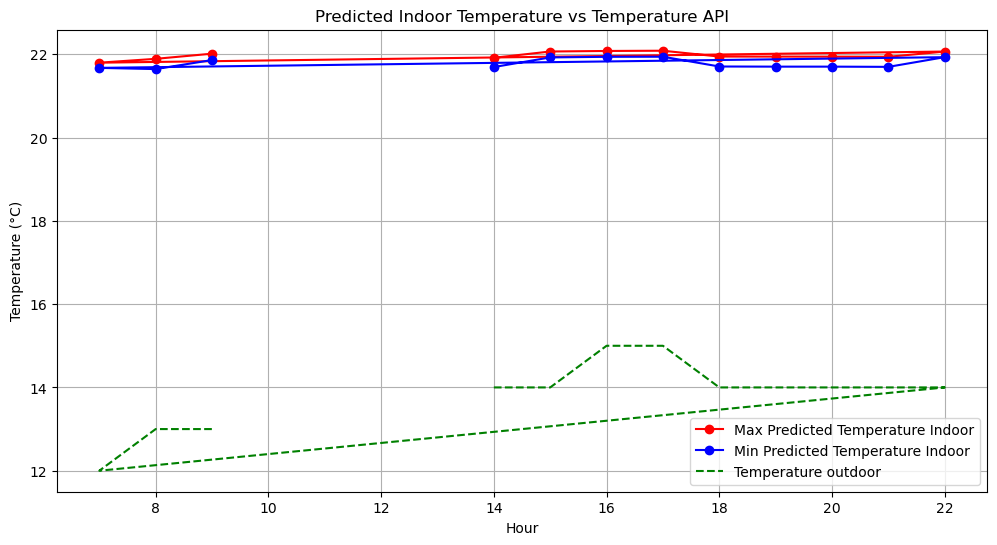

In [85]:
import matplotlib.pyplot as plt

# Plotting the predicted indoor temperatures from result_df_max and result_df_min
plt.figure(figsize=(12, 6))  # Set the figure size for better visibility

# Plot the predicted indoor temperature for maximum values
plt.plot(result_df_max['hr'], result_df_max['trend'], label='Max Predicted Temperature Indoor', color='red', marker='o')

# Plot the predicted indoor temperature for minimum values
plt.plot(result_df_min['hr'], result_df_min['trend'], label='Min Predicted Temperature Indoor', color='blue', marker='o')

# Plot the actual temperature from the API (assuming it's in the DataFrame)
plt.plot(result_df_min['hr'], result_df_min['Temperature_API'], label='Temperature outdoor', color='green', linestyle='--')

# Adding titles and labels
plt.title('Predicted Indoor Temperature vs Temperature API')
plt.xlabel('Hour')
plt.ylabel('Temperature (°C)')
plt.legend()  # Show legend to differentiate the lines
plt.grid()  # Add grid for better readability

# Show the plot
plt.show()

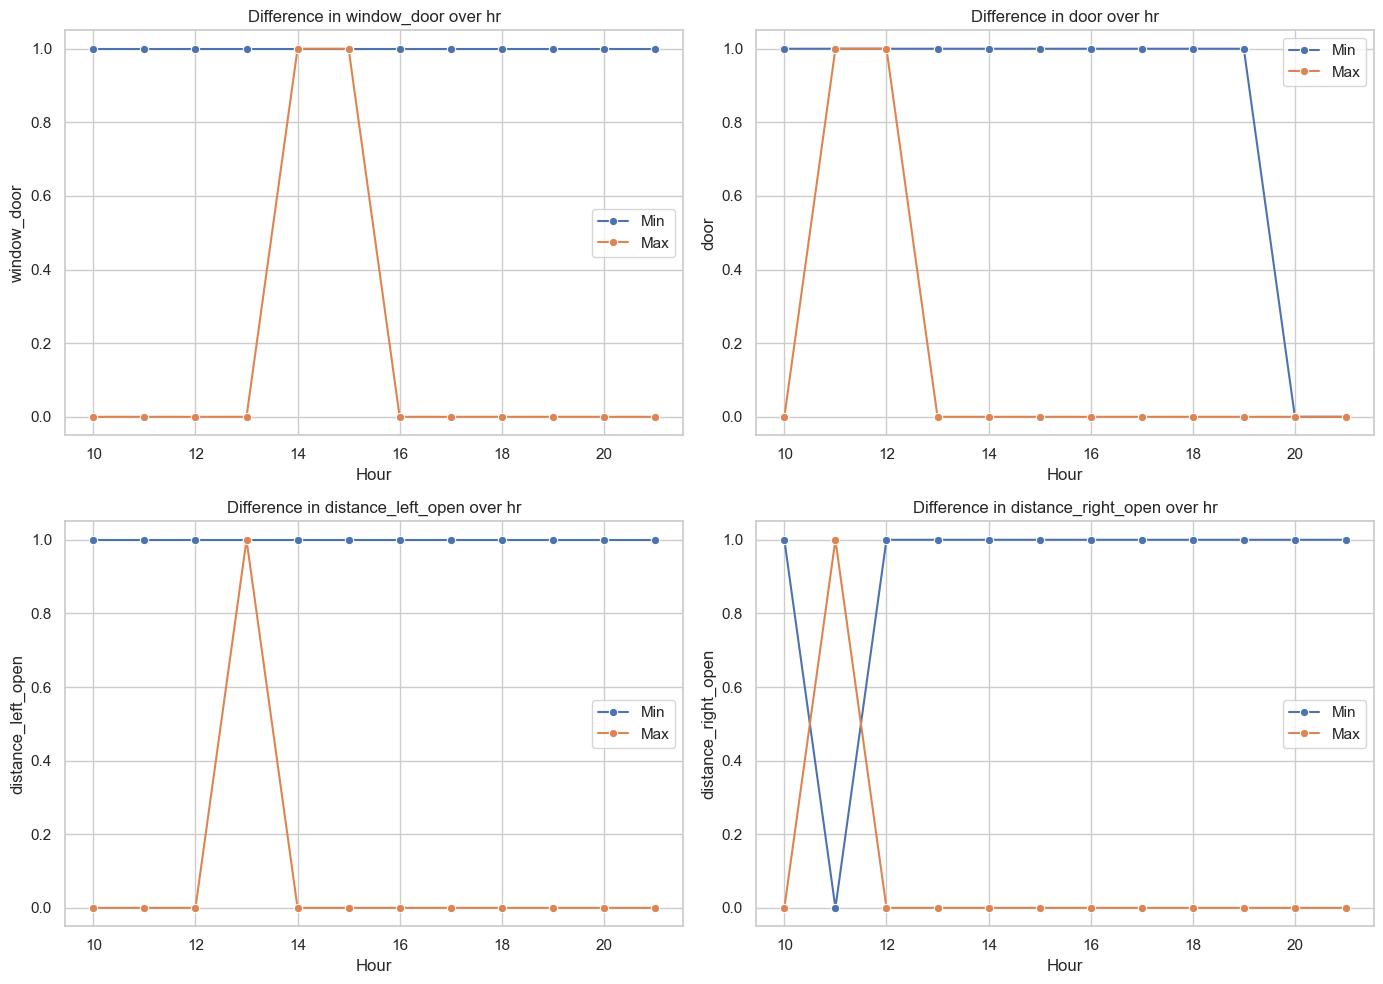

In [331]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming result_df_min and result_df_max are already defined

# Set the style of seaborn
sns.set(style="whitegrid")

# Create a figure for the plots
plt.figure(figsize=(14, 10))

# List of columns to visualize
columns_to_visualize = ['window_door', 'door', 'distance_left_open', 'distance_right_open']

# Loop through each column and create a line plot
for i, column in enumerate(columns_to_visualize):
    plt.subplot(2, 2, i + 1)  # Create a subplot for each column
    
    # Plot the minimum values
    sns.lineplot(data=result_df_min, x='hr', y=column, label='Min', marker='o')
    # Plot the maximum values
    sns.lineplot(data=result_df_max, x='hr', y=column, label='Max', marker='o')
    
    # Set the title and labels
    plt.title(f'Difference in {column} over hr')
    plt.xlabel('Hour')
    plt.ylabel(column)
    plt.legend()

# Adjust layout
plt.tight_layout()
plt.show()